Se comienza creando el enterno virtual, en este caso llamado .venv, y se activan los scripts.

Al comenzar el desarrollo, se preparan las librerias a utilizar: pandas, numpy, seaborn,matplotlib y el kernel con ipykernel para evitar problemas al momento de correr el enterno virtual.

In [1]:
# Importación de librerías esenciales
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Configuración de gráficos
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = [10, 6]

# Carga del dataset
df = pd.read_csv("spotify_data_clean.csv")

# Inspección de dimensiones y tipos
print(f"Dimensiones del dataset: {df.shape[0]} filas y {df.shape[1]} columnas.\n")
print("--- Estructura y Tipos de Datos ---")
df.info()

Dimensiones del dataset: 8582 filas y 15 columnas.

--- Estructura y Tipos de Datos ---
<class 'pandas.DataFrame'>
RangeIndex: 8582 entries, 0 to 8581
Data columns (total 15 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   track_id            8582 non-null   str    
 1   track_name          8582 non-null   str    
 2   track_number        8582 non-null   int64  
 3   track_popularity    8582 non-null   int64  
 4   explicit            8582 non-null   bool   
 5   artist_name         8579 non-null   str    
 6   artist_popularity   8582 non-null   int64  
 7   artist_followers    8582 non-null   int64  
 8   artist_genres       5221 non-null   str    
 9   album_id            8582 non-null   str    
 10  album_name          8582 non-null   str    
 11  album_release_date  8582 non-null   str    
 12  album_total_tracks  8582 non-null   int64  
 13  album_type          8582 non-null   str    
 14  track_duration_min  8582 no

In [3]:
df.head()

,track_id,track_name,track_number,track_popularity,explicit,artist_name,artist_popularity,artist_followers,artist_genres,album_id,album_name,album_release_date,album_total_tracks,album_type,track_duration_min
0,3EJS5LyekDim1Tf5rBFmZl,Trippy Mane (ft. Project Pat),4,0,True,Diplo,77,2812821,moombahton,5QRFnGnBeMGePBKF2xTz5z,"d00mscrvll, Vol. 1",2025-10-31,9,album,1.55
1,1oQW6G2ZiwMuHqlPpP27DB,OMG!,1,0,True,Yelawolf,64,2363438,"country hip hop, southern hip hop",4SUmmwnv0xTjRcLdjczGg2,OMG!,2025-10-31,1,single,3.07
2,7mdkjzoIYlf1rx9EtBpGmU,Hard 2 Find,1,4,True,Riff Raff,48,193302,NaN,3E3zEAL8gUYWaLYB9L7gbp,Hard 2 Find,2025-10-31,1,single,2.55
3,67rW0Zl7oB3qEpD5YWWE5w,Still Get Like That (ft. Project Pat & Starrah),8,30,True,Diplo,77,2813710,moombahton,5QRFnGnBeMGePBKF2xTz5z,"d00mscrvll, Vol. 1",2025-10-31,9,album,1.69
4,15xptTfRBrjsppW0INUZjf,ride me like a harley,2,0,True,Rumelis,48,8682,dark r&b,06FDIpSHYmZAZoyuYtc7kd,come closer / ride me like a harley,2025-10-30,2,single,2.39


# Tratamiento de Valores Nulos
Al inspeccionar el dataset, descubrimos que las variables numéricas y objetivo están completas. Solo encontramos nulos en variables de texto:
1. `artist_name` (3 nulos): Al ser un volumen insignificante, optamos por eliminar esos registros.
2. `artist_genres` (3361 nulos): Para no perder la valiosa información de miles de filas, imputamos estos valores vacios con la categoría "Desconocido".

In [4]:
# Eliminar filas donde el nombre del artista es nulo
# (Usamos df_limpio para mantener el original intacto)
df_limpio = df.dropna(subset=['artist_name']).copy()

# 2. Rellenar los nulos de los géneros musicales con "Desconocido"
df_limpio['artist_genres'] = df_limpio['artist_genres'].fillna('Desconocido')

# 3. Verificación de nulos
print("--- Control final de nulos ---")
print(df_limpio.isnull().sum())

--- Control final de nulos ---
track_id              0
track_name            0
track_number          0
track_popularity      0
explicit              0
artist_name           0
artist_popularity     0
artist_followers      0
artist_genres         0
album_id              0
album_name            0
album_release_date    0
album_total_tracks    0
album_type            0
track_duration_min    0
dtype: int64


# Filtrado de Ruido y Duplicados
Una vez que el dataset está completo (sin nulos), eliminamos registros que no aportan valor o son repetidos.

In [5]:
# Filtrar el ruido (Popularidad 0)
cantidad_original = len(df_limpio)
df_limpio = df_limpio[df_limpio['track_popularity'] > 0].copy()
print(f"Se eliminaron {cantidad_original - len(df_limpio)} canciones con popularidad 0.")

# Verificar duplicados (por ID)
duplicados_id = df_limpio.duplicated(subset=['track_id']).sum()
print(f"Canciones duplicadas por 'track_id': {duplicados_id}")

# Si hay, los eliminamos
if duplicados_id > 0:
    df_limpio = df_limpio.drop_duplicates(subset=['track_id'], keep='first')
    print("¡Duplicados eliminados exitosamente!")

Se eliminaron 503 canciones con popularidad 0.
Canciones duplicadas por 'track_id': 0


In [6]:
df_limpio["track_popularity"].unique()

array([ 4, 30,  2, 20, 27, 16, 33, 48, 65, 67, 31, 11, 35, 52, 22, 59,  1,
       32, 34, 42, 25, 13,  6, 29, 80, 51, 38,  3, 50, 72, 68, 88, 24, 70,
       79, 75, 37, 28, 74, 76, 18, 39, 60, 40, 87, 93, 53, 92, 97, 91, 55,
       95, 94, 36, 54, 23, 46, 26, 77, 17, 56, 43, 41, 85, 49, 90, 21, 78,
       44, 47, 71, 69, 58, 10, 15, 61, 84, 62, 66, 64, 82, 81, 57, 83, 14,
       89, 73, 45, 12, 63, 86, 19, 99,  5,  9,  7,  8])

# Transformación y Exportación
Esta es la celda técnica donde preparamos el "lenguaje" que entenderá el Random Forest.

In [7]:
df['album_type'].unique()

<StringArray>
['album', 'single', 'compilation']
Length: 3, dtype: str

In [8]:
# Transformar 'explicit' a binario
mapeo_explicito = {True: 1, False: 0, 'TRUE': 1, 'FALSE': 0, 'True': 1, 'False': 0}
df_limpio['explicit'] = df_limpio['explicit'].map(mapeo_explicito)

# Aplicar One-Hot Encoding a 'album_type'
# Convertimos categorías a columnas numéricas (0 y 1)
# df_limpio = pd.get_dummies(df_limpio, columns=['album_type'], drop_first=True, dtype=int)

df_limpio['album_type'] = df['album_type'].map({
    'album':1,
    'single':2,
    'compilation':3
    })


# Verificación final de la estructura
print("\n--- Estructura final de columnas ---")
print(df_limpio.dtypes)

# Exportación
archivo_salida = 'spotify_datos_preprocesados.csv'
df_limpio.to_csv(archivo_salida, index=False)
print(f"\n¡Procesamiento completo! Archivo guardado como: {archivo_salida}")


--- Estructura final de columnas ---
track_id                  str
track_name                str
track_number            int64
track_popularity        int64
explicit                int64
artist_name               str
artist_popularity       int64
artist_followers        int64
artist_genres             str
album_id                  str
album_name                str
album_release_date        str
album_total_tracks      int64
album_type              int64
track_duration_min    float64
dtype: object

¡Procesamiento completo! Archivo guardado como: spotify_datos_preprocesados.csv


In [9]:
df_limpio['album_type'].unique()

array([2, 1, 3])

# Visualizacion y analisis de datos

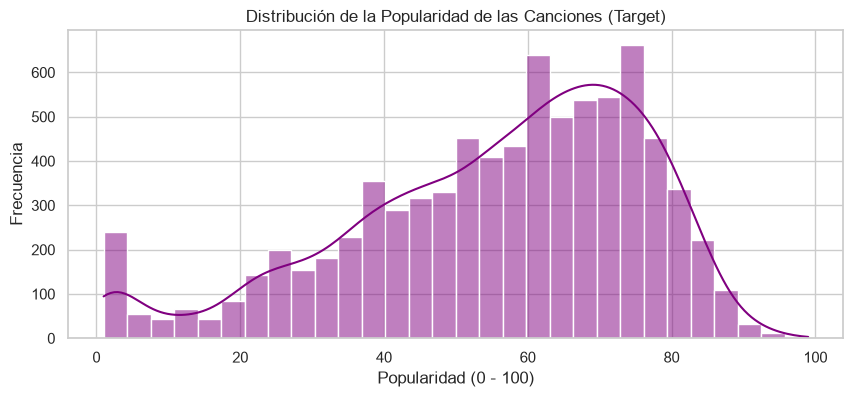

In [10]:
# Histograma de distribucion de la popularidad
plt.figure(figsize=(10, 4))
sns.histplot(df_limpio['track_popularity'], bins=30, kde=True, color='purple')
plt.title('Distribución de la Popularidad de las Canciones (Target)')
plt.xlabel('Popularidad (0 - 100)')
plt.ylabel('Frecuencia')
plt.show()


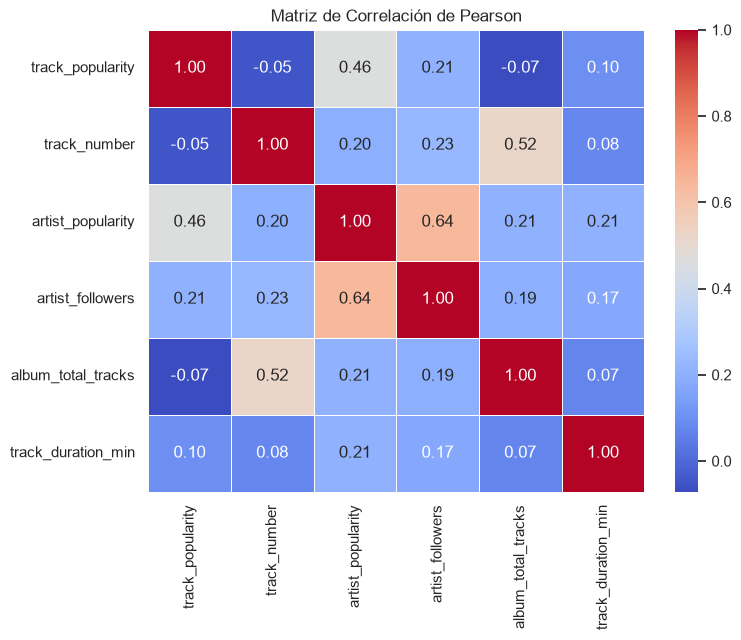

In [11]:
# Mapa de calor - matriz de correlacion numerico
columnas_numericas = ['track_popularity', 'track_number', 'artist_popularity', 
                    'artist_followers', 'album_total_tracks', 'track_duration_min']

matriz_corr = df_limpio[columnas_numericas].corr()

plt.figure(figsize=(8, 6))
sns.heatmap(matriz_corr, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title('Matriz de Correlación de Pearson')
plt.show()

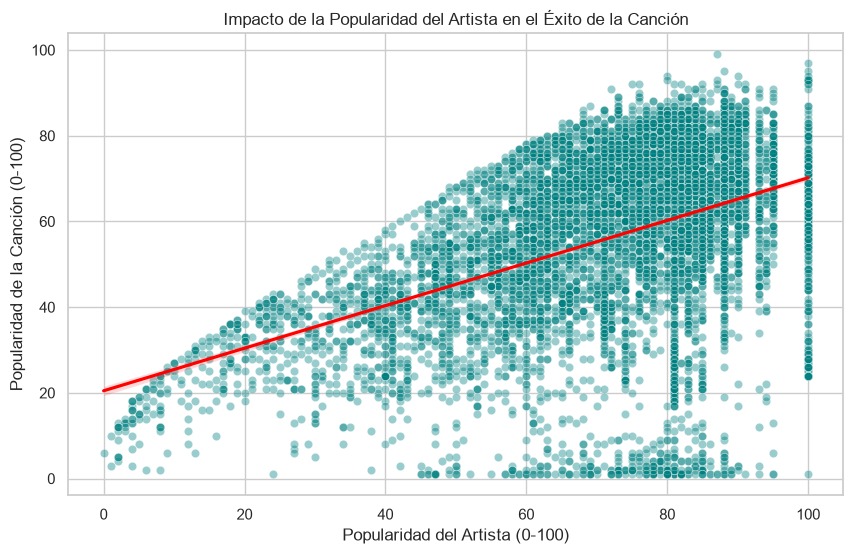

In [13]:
# Gráfico de Popularidad del Artista vs Popularidad de la Canción
plt.figure(figsize=(10, 6))

# Creamos el gráfico de puntos con un poco de transparencia (alpha) para ver la densidad
sns.scatterplot(data=df_limpio, x='artist_popularity', y='track_popularity', alpha=0.4, color='teal')

# Superponemos una línea de tendencia lineal para marcar la dirección de los datos
sns.regplot(data=df_limpio, x='artist_popularity', y='track_popularity', scatter=False, color='red')

plt.title('Impacto de la Popularidad del Artista en el Éxito de la Canción')
plt.xlabel('Popularidad del Artista (0-100)')
plt.ylabel('Popularidad de la Canción (0-100)')
plt.show()

## Modelado de Machine Learning (Random Forest)
En esta etapa, separaremos nuestros datos procesados en características predictoras ($X$) y la variable objetivo ($y$). Luego, dividiremos el conjunto en datos de entrenamiento (80%) y prueba (20%) para entrenar un modelo `RandomForestRegressor` y evaluar su rendimiento. Finalmente, exportaremos el modelo entrenado.

In [4]:
# Importamos las herramientas necesarias de Scikit-Learn y Joblib
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score
import joblib
import pandas as pd # Por si reiniciaste el notebook

# 1. Cargar el dataset limpio (si es necesario)
df_final = pd.read_csv('spotify_datos_preprocesados.csv')

# 2. Separar X (Características) e y (Objetivo)
# Excluimos las columnas de texto/IDs que no le sirven al algoritmo matemático
columnas_a_excluir = ['track_id', 'track_name', 'artist_name', 'artist_genres', 'album_id', 'album_name', 'album_release_date', 'track_popularity']

X = df_final.drop(columns=columnas_a_excluir)
y = df_final['track_popularity']

# 3. Dividir en Entrenamiento (80%) y Prueba (20%)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print(f"Datos de entrenamiento: {X_train.shape[0]} canciones.")
print(f"Datos de prueba: {X_test.shape[0]} canciones.\n")

# 4. Inicializar y Entrenar el Modelo
print("Entrenando el Random Forest... (esto puede tomar unos segundos)")
modelo_rf = RandomForestRegressor(n_estimators=100, random_state=42)
modelo_rf.fit(X_train, y_train)

# 5. Hacer predicciones con los datos de prueba
predicciones = modelo_rf.predict(X_test)

# 6. Evaluar el modelo
r2 = r2_score(y_test, predicciones)
mse = mean_squared_error(y_test, predicciones)
rmse = mse ** 0.5

print("--- Métricas de Rendimiento ---")
print(f"R² Score: {r2:.4f} (Mide qué tan bien explica el modelo la varianza)")
print(f"RMSE: {rmse:.2f} (Error promedio en puntos de popularidad)")

# 7. Exportar el modelo entrenado (Requisito de la rúbrica)
ruta_modelo = 'modelo_spotify.pkl'
joblib.dump(modelo_rf, ruta_modelo)
print(f"\n¡Modelo exportado exitosamente como '{ruta_modelo}'!")

Datos de entrenamiento: 6460 canciones.
Datos de prueba: 1616 canciones.

Entrenando el Random Forest... (esto puede tomar unos segundos)
--- Métricas de Rendimiento ---
R² Score: 0.3187 (Mide qué tan bien explica el modelo la varianza)
RMSE: 17.08 (Error promedio en puntos de popularidad)

¡Modelo exportado exitosamente como 'modelo_spotify.pkl'!
